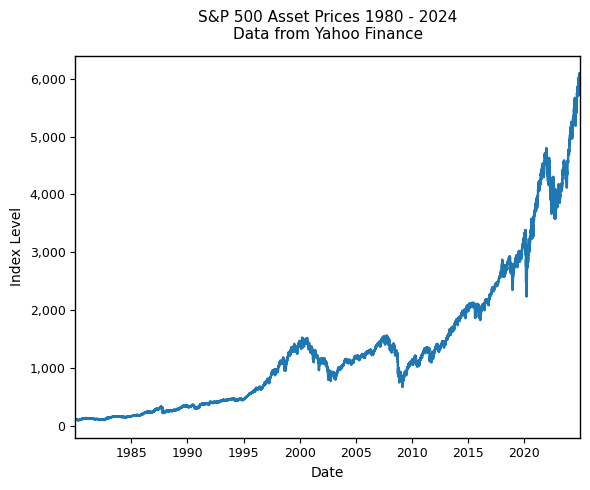

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Figure 1.1 — S&P 500 raw price series
# This notebook downloads S&P 500 historical prices from Yahoo Finance
# and exports the figure used in Chapter 1 of the thesis

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style settings
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Data download and cleaning
df = yf.download(
    "^GSPC",
    start="1980-01-01",
    end="2024-12-31",
    interval="1d",
    progress=False
)

# Handle possible multi-level columns returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Remove missing observations
df = df.dropna()

# Figure construction
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    df.index,
    df["Close"],
    linewidth=1.8,
    color="#1f77b4"
)

ax.set_title(
    "S&P 500 Asset Prices 1980 - 2024\nData from Yahoo Finance",
    pad=12
)
ax.set_xlabel("Date")
ax.set_ylabel("Index Level")
ax.set_xlim(df.index.min(), df.index.max())
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

for spine in ax.spines.values():
    spine.set_linewidth(1)

ax.grid(False)

if ax.get_legend():
    ax.get_legend().remove()

# Export figure for the thesis
plt.tight_layout()
output_path = OUTPUT_DIR / "fig_1_1_prices.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()